# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





**Github Link**: https://github.com/DanNtwali/PCA_Team9/



### Data Handling (before Step 1)
**Dataset:** `a_general_1.csv`, a 2013 farm household survey from Rwanda (300 farms, 16 columns) covering five action sites: Bugesera, Burera, Gakenke, Kamonyi and Kayonza.

PCA only works on a complete numeric matrix, so the raw file is first inspected, cleaned, imputed and encoded. Only `numpy` is used for the computation (`matplotlib` is used for the plots only).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=120)

In [ ]:
# Load everything as text first so missing and non-numeric values are visible
DATA_PATH = "a_general_1.csv"

raw = np.genfromtxt(DATA_PATH, delimiter=",", dtype=str, comments=None, encoding="utf-8")
columns = raw[0]
data = np.char.strip(raw[1:])  # trims stray spaces, e.g. "Gitovu " vs "Gitovu"
n_rows = data.shape[0]

print(f"Rows: {n_rows}, Columns: {len(columns)}")
print(", ".join(columns))

Rows: 300, Columns: 16
SN, id, farm_id, date_interview_dd, date_interview_mm, date_interview_yyyy, country, sector_state, action_site, village, gps_latitude, gps_longitude, gps_altitude, gps_latitude_dec, gps_longitude_dec, instanceid


In [ ]:
def is_numeric(values):
    """True if every non-missing entry can be read as a number."""
    try:
        values[values != ""].astype(float)
        return True
    except ValueError:
        return False


print(f"{'column':<22}{'type':<14}{'missing':>8}{'unique':>8}")
for name, col in zip(columns, data.T):
    present = col[col != ""]
    kind = "empty" if present.size == 0 else "numeric" if is_numeric(col) else "non-numeric"
    print(f"{name:<22}{kind:<14}{n_rows - present.size:>8}{np.unique(present).size:>8}")

column                type           missing  unique
SN                    numeric              0     300
id                    numeric              0     300
farm_id               non-numeric          0     300
date_interview_dd     numeric              1      20
date_interview_mm     numeric              1       3
date_interview_yyyy   numeric              1       1
country               non-numeric          0       1
sector_state          non-numeric          0      18
action_site           non-numeric          0       5
village               non-numeric          1     105
gps_latitude          empty              300       0
gps_longitude         empty              300       0
gps_altitude          numeric              1     236
gps_latitude_dec      numeric              0       9
gps_longitude_dec     numeric              0       8
instanceid            empty              300       0


The table above shows the problems to fix: three columns are completely empty, four more have a missing value, and `farm_id`, `country`, `sector_state`, `action_site` and `village` are non-numeric.

In [ ]:
# Columns that cannot contribute variance are removed before PCA
keep = []
for j, (name, col) in enumerate(zip(columns, data.T)):
    n_unique = np.unique(col[col != ""]).size
    if n_unique == 0:
        reason = "entirely missing, nothing to impute from"
    elif n_unique == 1:
        reason = "constant, zero variance"
    elif n_unique == n_rows:
        reason = "row identifier, unique for every farm"
    else:
        keep.append(j)
        continue
    print(f"dropped {name:<22}{reason}")

columns, data = columns[keep], data[:, keep]
print(f"\nKept {len(columns)} columns: {', '.join(columns)}")

dropped SN                    row identifier, unique for every farm
dropped id                    row identifier, unique for every farm
dropped farm_id               row identifier, unique for every farm
dropped date_interview_yyyy   constant, zero variance
dropped country               constant, zero variance
dropped gps_latitude          entirely missing, nothing to impute from
dropped gps_longitude         entirely missing, nothing to impute from
dropped instanceid            entirely missing, nothing to impute from

Kept 8 columns: date_interview_dd, date_interview_mm, sector_state, action_site, village, gps_altitude, gps_latitude_dec, gps_longitude_dec


In [ ]:
# Impute: median for numeric columns, most frequent category for non-numeric ones
numeric_mask = np.array([is_numeric(col) for col in data.T])

for j, name in enumerate(columns):
    missing = data[:, j] == ""
    if not missing.any():
        continue
    present = data[~missing, j]
    if numeric_mask[j]:
        fill = f"{np.median(present.astype(float)):g}"
    else:
        categories, counts = np.unique(present, return_counts=True)
        fill = categories[counts.argmax()]
    data[missing, j] = fill
    print(f"{name:<22}filled {missing.sum()} missing value(s) with {fill}")

print(f"\nMissing values remaining: {(data == '').sum()}")

date_interview_dd     filled 1 missing value(s) with 5
date_interview_mm     filled 1 missing value(s) with 5
village               filled 1 missing value(s) with Kagesera
gps_altitude          filled 1 missing value(s) with 1649

Missing values remaining: 0


In [ ]:
# Encode non-numeric columns: one-hot when there are few categories,
# frequency encoding otherwise (one-hot on ~100 villages would swamp the PCA)
ONE_HOT_MAX_CATEGORIES = 10

features, feature_names = [], []
for j, name in enumerate(columns):
    col = data[:, j]
    if numeric_mask[j]:
        features.append(col.astype(float))
        feature_names.append(str(name))
        continue

    categories, inverse, counts = np.unique(col, return_inverse=True, return_counts=True)
    if len(categories) <= ONE_HOT_MAX_CATEGORIES:
        features.extend((inverse == k).astype(float) for k in range(len(categories)))
        feature_names.extend(f"{name}={c}" for c in categories)
        print(f"{name:<14}one-hot encoded   ({len(categories)} categories)")
    else:
        features.append(counts[inverse] / n_rows)
        feature_names.append(f"{name}_freq")
        print(f"{name:<14}frequency encoded ({len(categories)} categories)")

X = np.column_stack(features)
site_labels = data[:, list(columns).index("action_site")]  # kept only to colour the plots

print(f"\nNumeric feature matrix: {X.shape}")
print(feature_names)

sector_state  frequency encoded (18 categories)
action_site   one-hot encoded   (5 categories)
village       frequency encoded (105 categories)

Numeric feature matrix: (300, 12)
['date_interview_dd', 'date_interview_mm', 'sector_state_freq', 'action_site=Bugesera', 'action_site=Burera', 'action_site=Gakenke', 'action_site=Kamonyi', 'action_site=Kayonza', 'village_freq', 'gps_altitude', 'gps_latitude_dec', 'gps_longitude_dec']


**How each issue is handled**
- **Dropped:** empty columns (nothing to impute from), constant columns (zero variance, so standardization would divide by 0) and row identifiers (unique per farm, they carry no shared structure).
- **Imputed:** numeric columns with the **median** (robust to outliers such as extreme altitudes), non-numeric columns with the **mode** (most frequent category).
- **Encoded:** `action_site` (5 categories) is **one-hot** encoded so no artificial order is implied. `sector_state` (18) and `village` (105) are **frequency** encoded, since one-hot would add 123 sparse columns that would dominate the variance.

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

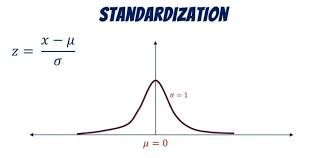


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = X.mean(axis=0)
std = X.std(axis=0)

standardized_data = (X - mean) / std  # z = (x - mu) / sigma
standardized_data[:5]  # Display the first few rows of standardized data

array([[-0.6679, -0.1502, -0.1168,  2.    , -0.5   , -0.5   , -0.5   , -0.5   , -0.157 , -1.0874, -1.2632,  0.3579],
       [-0.6679, -0.1502, -0.1168,  2.    , -0.5   , -0.5   , -0.5   , -0.5   , -0.2816, -1.1416, -1.2632,  0.3579],
       [-0.6679, -0.1502, -0.1168,  2.    , -0.5   , -0.5   , -0.5   , -0.5   , -0.0324, -1.0874, -1.2632,  0.3579],
       [-0.3707, -0.1502, -0.1168,  2.    , -0.5   , -0.5   , -0.5   , -0.5   , -0.0324, -1.1499, -1.2632,  0.3579],
       [-0.3707, -0.1502, -0.1168,  2.    , -0.5   , -0.5   , -0.5   , -0.5   , -0.2816, -1.3874, -1.2632,  0.3579]])

In [ ]:
# Every feature should now have mean 0 and standard deviation 1
print("means:", standardized_data.mean(axis=0).round(10) + 0)
print("stds :", standardized_data.std(axis=0))

means: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
stds : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
# The data is already centred, so cov = Z^T Z / (n - 1)
cov_matrix = standardized_data.T @ standardized_data / (n_rows - 1)

assert np.allclose(cov_matrix, np.cov(standardized_data, rowvar=False))
print(f"Shape: {cov_matrix.shape}")
cov_matrix

Shape: (12, 12)


array([[ 1.0033, -0.0929, -0.0666, -0.0874, -0.0303,  0.0161,  0.2372, -0.1355, -0.0595,  0.048 , -0.0029, -0.1789],
       [-0.0929,  1.0033,  0.1886, -0.1617,  0.38  ,  0.1994, -0.2795, -0.1382,  0.2283,  0.3839,  0.5022, -0.3133],
       [-0.0666,  0.1886,  1.0033, -0.1658,  0.3572,  0.1323, -0.2913, -0.0324,  0.4249,  0.3853,  0.4123, -0.1525],
       [-0.0874, -0.1617, -0.1658,  1.0033, -0.2508, -0.2508, -0.2508, -0.2508, -0.1851, -0.5782, -0.6698,  0.1567],
       [-0.0303,  0.38  ,  0.3572, -0.2508,  1.0033, -0.2508, -0.2508, -0.2508,  0.6756,  0.7816,  0.6217, -0.338 ],
       [ 0.0161,  0.1994,  0.1323, -0.2508, -0.2508,  1.0033, -0.2508, -0.2508, -0.1215,  0.2658,  0.4625, -0.4924],
       [ 0.2372, -0.2795, -0.2913, -0.2508, -0.2508, -0.2508,  1.0033, -0.2508, -0.2642, -0.1346, -0.3844, -0.2122],
       [-0.1355, -0.1382, -0.0324, -0.2508, -0.2508, -0.2508, -0.2508,  1.0033, -0.1048, -0.3347, -0.03  ,  0.8858],
       [-0.0595,  0.2283,  0.4249, -0.1851,  0.6756, -0.1215, -0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

**Why compute the covariance matrix?** First, it measures how every pair of features varies together, which exposes redundancy: here `gps_altitude` and `gps_latitude_dec` have a covariance of 0.84, so they largely repeat the same information and can be merged into one direction. Second, its eigenvectors give the directions of maximum variance (the principal components) and its eigenvalues give how much variance each direction holds, which is exactly what PCA needs to rank and select components. Because the data is standardized, its diagonal is about 1 for every feature, so no feature dominates just because of its units (metres vs degrees).

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 4: Perform Eigendecomposition
# eigh is used because a covariance matrix is symmetric: it guarantees real
# eigenvalues and orthonormal eigenvectors (one per column)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.    , 0.0103, 0.015 , 0.0597, 0.3937, 0.5934, 0.7999, 0.8766, 1.4248, 1.5101, 2.1125, 4.2442]),
 array([[ 0.    , -0.0237,  0.0249,  0.0112, -0.0279,  0.0418, -0.5652, -0.7001,  0.3342,  0.0299,  0.2718, -0.0064],
        [ 0.    , -0.0455,  0.0479,  0.0931, -0.2322,  0.596 , -0.5539,  0.3641, -0.2336, -0.0831, -0.0518, -0.2726],
        [ 0.    , -0.0286,  0.0302,  0.0267,  0.1835,  0.6254,  0.4759, -0.478 , -0.1118,  0.0398, -0.1982, -0.2537],
        [-0.4472,  0.0053, -0.4141,  0.1895,  0.0828, -0.0473, -0.1314, -0.1598, -0.5829,  0.3701,  0.0431,  0.2492],
        [-0.4472, -0.1471,  0.4334, -0.2866,  0.3472, -0.1492, -0.1345,  0.1028,  0.0875,  0.403 , -0.1579, -0.3767],
        [-0.4472, -0.2186,  0.252 , -0.02  , -0.2879, -0.1741,  0.1385, -0.1625, -0.2919, -0.5943,  0.2457, -0.1754],
        [-0.4472, -0.1725, -0.2381,  0.01  , -0.1484,  0.3268,  0.2302,  0.2474,  0.5187,  0.1357,  0.4072,  0.1308],
        [-0.4472,  0.5328, -0.0333,  0.1072,  0.0063,  0.0439, -0.10

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly

print("Sorted eigenvalues:", sorted_eigenvalues)
sorted_eigenvectors

Sorted eigenvalues: [4.2442 2.1125 1.5101 1.4248 0.8766 0.7999 0.5934 0.3937 0.0597 0.015  0.0103 0.    ]


array([[-0.0064,  0.2718,  0.0299,  0.3342, -0.7001, -0.5652,  0.0418, -0.0279,  0.0112,  0.0249, -0.0237,  0.    ],
       [-0.2726, -0.0518, -0.0831, -0.2336,  0.3641, -0.5539,  0.596 , -0.2322,  0.0931,  0.0479, -0.0455,  0.    ],
       [-0.2537, -0.1982,  0.0398, -0.1118, -0.478 ,  0.4759,  0.6254,  0.1835,  0.0267,  0.0302, -0.0286,  0.    ],
       [ 0.2492,  0.0431,  0.3701, -0.5829, -0.1598, -0.1314, -0.0473,  0.0828,  0.1895, -0.4141,  0.0053, -0.4472],
       [-0.3767, -0.1579,  0.403 ,  0.0875,  0.1028, -0.1345, -0.1492,  0.3472, -0.2866,  0.4334, -0.1471, -0.4472],
       [-0.1754,  0.2457, -0.5943, -0.2919, -0.1625,  0.1385, -0.1741, -0.2879, -0.02  ,  0.252 , -0.2186, -0.4472],
       [ 0.1308,  0.4072,  0.1357,  0.5187,  0.2474,  0.2302,  0.3268, -0.1484,  0.01  , -0.2381, -0.1725, -0.4472],
       [ 0.1721, -0.5381, -0.3146,  0.2686, -0.0278, -0.1028,  0.0439,  0.0063,  0.1072, -0.0333,  0.5328, -0.4472],
       [-0.2985, -0.2494,  0.3698,  0.0468, -0.1375,  0.1154, -0

#### Explained variance
Each eigenvalue is the variance captured by its principal component, so `eigenvalue / sum(eigenvalues)` is the share of total variance it explains. The last eigenvalue is 0 because the five one-hot `action_site` columns always sum to 1, so one of them is fully redundant.

In [ ]:
# Explained variance: each eigenvalue as a share of the total variance
explained_variance = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance)

print(f"{'PC':<6}{'eigenvalue':>11}{'explained %':>13}{'cumulative %':>14}")
for i, (val, ev, cv) in enumerate(zip(sorted_eigenvalues, explained_variance, cumulative_variance), 1):
    print(f"PC{i:<4}{val:>11.4f}{ev * 100:>13.2f}{cv * 100:>14.2f}")

PC     eigenvalue  explained %  cumulative %
PC1        4.2442        35.25         35.25
PC2        2.1125        17.55         52.80
PC3        1.5101        12.54         65.34
PC4        1.4248        11.83         77.17
PC5        0.8766         7.28         84.45
PC6        0.7999         6.64         91.10
PC7        0.5934         4.93         96.02
PC8        0.3937         3.27         99.29
PC9        0.0597         0.50         99.79
PC10       0.0150         0.12         99.91
PC11       0.0103         0.09        100.00
PC12       0.0000         0.00        100.00


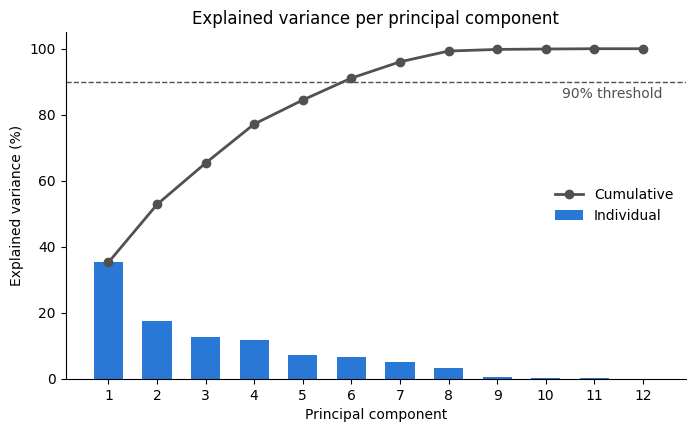

In [ ]:
VARIANCE_THRESHOLD = 0.90

pcs = np.arange(1, len(sorted_eigenvalues) + 1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(pcs, explained_variance * 100, color="#2a78d6", width=0.6, label="Individual")
ax.plot(pcs, cumulative_variance * 100, color="#52514e", marker="o", linewidth=2, label="Cumulative")
ax.axhline(VARIANCE_THRESHOLD * 100, color="#52514e", linestyle="--", linewidth=1)
ax.text(pcs[-1] + 0.4, VARIANCE_THRESHOLD * 100 - 5, f"{VARIANCE_THRESHOLD:.0%} threshold", ha="right", color="#52514e")
ax.set(xlabel="Principal component", ylabel="Explained variance (%)", xticks=pcs,
       title="Explained variance per principal component")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="center right")
plt.show()

**Choosing the number of components.** The cumulative curve crosses the 90% line at **PC6 (91.1%)**, so 6 of the 12 components are kept, halving the dimensions while losing under 9% of the variance. The eigenvalue order supports this: PC1 to PC4 have eigenvalues above 1 (each holds more than one original feature's worth of variance) but together reach only 77%, and PC9 to PC12 are close to 0, so they are noise or redundancy.

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 6: Project Data onto Principal Components
# Keep the fewest components whose cumulative explained variance reaches the threshold
num_components = int(np.argmax(cumulative_variance >= VARIANCE_THRESHOLD) + 1)
print(f"Components kept: {num_components} of {len(sorted_eigenvalues)} "
      f"({cumulative_variance[num_components - 1]:.2%} of variance retained)")
print(f"Components with eigenvalue > 1 (Kaiser rule): {(sorted_eigenvalues > 1).sum()}")

reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]
reduced_data[:5]

Components kept: 6 of 12 (91.10% of variance retained)
Components with eigenvalue > 1 (Kaiser rule): 4


array([[ 1.8996, -0.0859,  1.1519, -1.8535, -0.0005,  0.0935],
       [ 1.9616, -0.0565,  1.1037, -1.8676,  0.014 ,  0.0766],
       [ 1.8624, -0.117 ,  1.198 , -1.8477, -0.0177,  0.1079],
       [ 1.8891, -0.0381,  1.2044, -1.7579, -0.2287, -0.063 ],
       [ 2.0722,  0.0167,  1.1029, -1.8058, -0.2056, -0.1031]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (300, 6)


array([[ 1.8996, -0.0859,  1.1519, -1.8535, -0.0005,  0.0935],
       [ 1.9616, -0.0565,  1.1037, -1.8676,  0.014 ,  0.0766],
       [ 1.8624, -0.117 ,  1.198 , -1.8477, -0.0177,  0.1079],
       [ 1.8891, -0.0381,  1.2044, -1.7579, -0.2287, -0.063 ],
       [ 2.0722,  0.0167,  1.1029, -1.8058, -0.2056, -0.1031]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

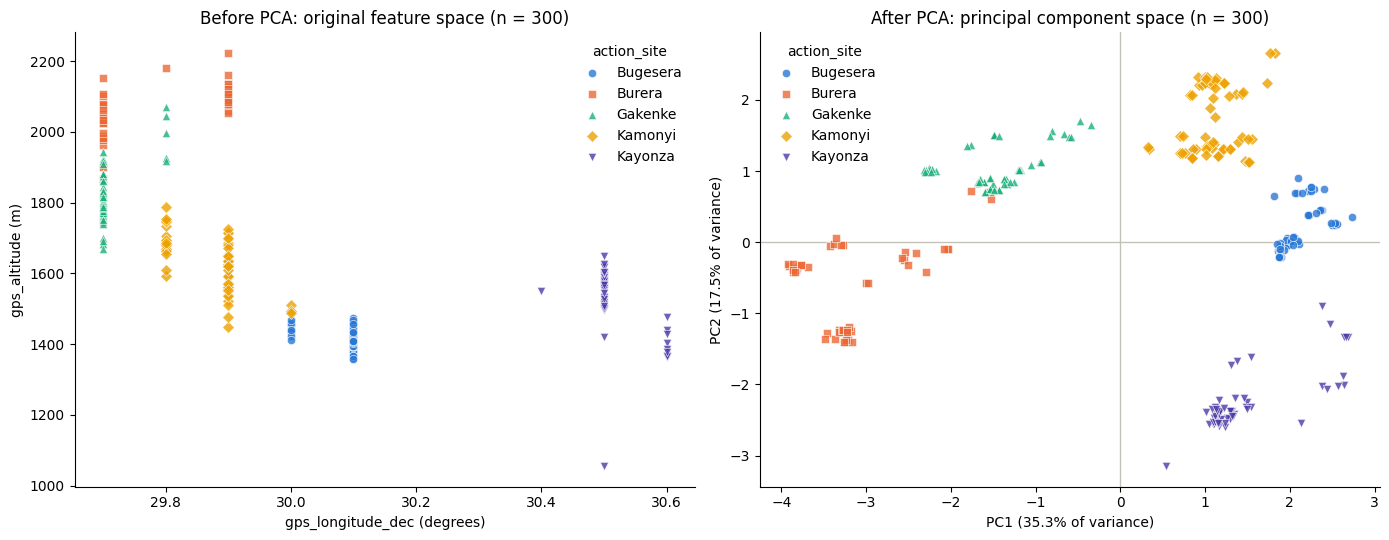

In [ ]:
# Step 8: Visualize Before and After PCA
SITE_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#4a3aa7"]
SITE_MARKERS = ["o", "s", "^", "D", "v"]  # shape backs up colour for colour-blind readers
x_feat, y_feat = feature_names.index("gps_longitude_dec"), feature_names.index("gps_altitude")

fig, (ax_before, ax_after) = plt.subplots(1, 2, figsize=(14, 5.5))

for site, color, marker in zip(np.unique(site_labels), SITE_COLORS, SITE_MARKERS):
    rows = site_labels == site
    style = dict(color=color, marker=marker, s=36, alpha=0.8, edgecolor="white", linewidth=0.5, label=site)
    # Plot original data (two of the original features)
    ax_before.scatter(X[rows, x_feat], X[rows, y_feat], **style)
    # Plot reduced data after PCA
    ax_after.scatter(reduced_data[rows, 0], reduced_data[rows, 1], **style)

ax_before.set(xlabel="gps_longitude_dec (degrees)", ylabel="gps_altitude (m)",
              title=f"Before PCA: original feature space (n = {len(X)})")
ax_after.set(xlabel=f"PC1 ({explained_variance[0]:.1%} of variance)",
             ylabel=f"PC2 ({explained_variance[1]:.1%} of variance)",
             title=f"After PCA: principal component space (n = {len(reduced_data)})")
ax_after.axhline(0, color="#c3c2b7", linewidth=1, zorder=0)
ax_after.axvline(0, color="#c3c2b7", linewidth=1, zorder=0)

for ax in (ax_before, ax_after):
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="action_site", frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# Sanity checks on the projection
pc_variance = reduced_data.var(axis=0, ddof=1)
print(f"Points before / after : {len(X)} / {len(reduced_data)}")
print(f"PC means (centred)    : {reduced_data.mean(axis=0).round(10) + 0}")
print(f"PC variances          : {pc_variance}")
print(f"Match the eigenvalues : {np.allclose(pc_variance, sorted_eigenvalues[:num_components])}")
print(f"Variance is descending: {bool(np.all(np.diff(pc_variance) <= 0))}")

Points before / after : 300 / 300
PC means (centred)    : [0. 0. 0. 0. 0. 0.]
PC variances          : [4.2442 2.1125 1.5101 1.4248 0.8766 0.7999]
Match the eigenvalues : True
Variance is descending: True


In [ ]:
# Helper for the written answers: what each kept PC is made of, and what the dropped PCs cost per feature
kept = sorted_eigenvectors[:, :num_components]

print("Largest loadings (by absolute value) on the first 3 PCs")
for k in range(3):
    top = np.argsort(np.abs(kept[:, k]))[::-1][:3]
    print(f"PC{k + 1}: " + ", ".join(f"{feature_names[j]} ({kept[j, k]:+.2f})" for j in top))

# Share of each feature's variance that survives in the kept components
retained = (kept ** 2 * sorted_eigenvalues[:num_components]).sum(axis=1) / np.diag(cov_matrix)
print(f"\n{'feature':<24}{'variance kept':>14}")
for j in np.argsort(retained):
    print(f"{feature_names[j]:<24}{retained[j]:>13.1%}")

Largest loadings (by absolute value) on the first 3 PCs
PC1: gps_altitude (-0.46), gps_latitude_dec (-0.43), action_site=Burera (-0.38)
PC2: action_site=Kayonza (-0.54), gps_longitude_dec (-0.52), action_site=Kamonyi (+0.41)
PC3: action_site=Gakenke (-0.59), action_site=Burera (+0.40), action_site=Bugesera (+0.37)

feature                  variance kept
village_freq                    74.4%
sector_state_freq               75.5%
date_interview_mm               76.8%
action_site=Kamonyi             92.7%
gps_altitude                    92.7%
action_site=Burera              93.2%
action_site=Gakenke             94.8%
gps_latitude_dec                95.6%
gps_longitude_dec               98.9%
action_site=Bugesera            99.1%
action_site=Kayonza             99.5%
date_interview_dd               99.9%


### Task 3: Performance Optimization and Benchmarking
The same PCA pipeline (standardize, covariance, eigendecomposition, sort) is implemented five ways and timed on datasets from 300 to 1,000,000 rows:

- **naive loops**: explicit Python loops for the mean, standard deviation, standardization and covariance (baseline).
- **vectorized**: NumPy array operations and one matrix product, `Z.T @ Z`, for the covariance.
- **SVD**: skips the covariance matrix and takes the singular values of the standardized data, since eigenvalue = s² / (n - 1).
- **chunked**: reads the data in blocks and accumulates the covariance, so the full standardized matrix is never held in memory.
- **float32**: the vectorized version in single precision.

Larger datasets are built by resampling the real rows with small random noise, so they are for timing only. The naive version is limited to 10,000 rows because it becomes too slow beyond that.

In [ ]:
import time
import tracemalloc  # standard library, used only to measure memory

def best_time(fn, *args, repeats=3):
    best = np.inf
    for _ in range(repeats):
        start = time.perf_counter()
        fn(*args)
        best = min(best, time.perf_counter() - start)
    return best

In [ ]:
def sort_desc(vals, vecs):
    order = np.argsort(vals)[::-1]
    return vals[order], vecs[:, order]

def pca_naive(X):
    n, d = X.shape
    mean = np.zeros(d); std = np.zeros(d)
    for j in range(d):
        total = 0.0
        for i in range(n):
            total += X[i, j]
        mean[j] = total / n
        sq = 0.0
        for i in range(n):
            sq += (X[i, j] - mean[j]) ** 2
        std[j] = (sq / n) ** 0.5
    Z = np.zeros((n, d))
    for i in range(n):
        for j in range(d):
            Z[i, j] = (X[i, j] - mean[j]) / std[j]
    cov = np.zeros((d, d))
    for a in range(d):
        for b in range(a, d):
            total = 0.0
            for i in range(n):
                total += Z[i, a] * Z[i, b]
            cov[a, b] = cov[b, a] = total / (n - 1)
    return sort_desc(*np.linalg.eigh(cov))

def standardize(X):
    std = X.std(axis=0)
    return (X - X.mean(axis=0)) / np.where(std == 0, 1, std)

def pca_vectorized(X):
    Z = standardize(X)
    cov = Z.T @ Z / (len(Z) - 1)
    return sort_desc(*np.linalg.eigh(cov))

def pca_svd(X):
    Z = standardize(X)
    _, s, Vt = np.linalg.svd(Z, full_matrices=False)
    return s ** 2 / (len(Z) - 1), Vt.T

def pca_chunked(X, chunk=50_000):
    n, d = X.shape
    total = np.zeros(d)
    for a in range(0, n, chunk):
        total += X[a:a + chunk].sum(axis=0)
    mean = total / n
    sq = np.zeros(d)
    for a in range(0, n, chunk):
        sq += ((X[a:a + chunk] - mean) ** 2).sum(axis=0)
    std = np.sqrt(sq / n)
    std = np.where(std == 0, 1, std)
    gram = np.zeros((d, d))
    for a in range(0, n, chunk):
        Zc = (X[a:a + chunk] - mean) / std
        gram += Zc.T @ Zc
    return sort_desc(*np.linalg.eigh(gram / (n - 1)))

def pca_float32(X):
    return pca_vectorized(X.astype(np.float32))

**Check that every version gives the same answer** before comparing speed. Eigenvector signs can flip between methods, so the eigenvalues are compared.

In [ ]:
# a small chunk size so that several blocks are used even on 300 rows
methods = {"naive loops": pca_naive, "vectorized": pca_vectorized, "SVD": pca_svd,
           "chunked": lambda A: pca_chunked(A, chunk=70), "float32": pca_float32}
reference = pca_vectorized(X)[0]
for name, fn in methods.items():
    vals = fn(X)[0]
    print(f"{name:<12} max abs diff in eigenvalues: {np.max(np.abs(vals - reference)):.2e}")

naive loops  max abs diff in eigenvalues: 1.61e-15
vectorized   max abs diff in eigenvalues: 0.00e+00
SVD          max abs diff in eigenvalues: 7.99e-15
chunked      max abs diff in eigenvalues: 5.33e-15
float32      max abs diff in eigenvalues: 7.29e-06


In [ ]:
def make_large(X, n_rows, seed=42):
    rng = np.random.default_rng(seed)
    reps = int(np.ceil(n_rows / len(X)))
    big = np.tile(X, (reps, 1))[:n_rows]
    return big + rng.normal(0, 0.05, big.shape) * X.std(axis=0)

In [ ]:
sizes = [300, 1_000, 10_000, 100_000, 1_000_000]
NAIVE_LIMIT = 10_000
fns = {"naive loops": pca_naive, "vectorized": pca_vectorized, "SVD": pca_svd,
       "chunked": pca_chunked, "float32": pca_float32}
results = {k: [] for k in fns}
for n in sizes:
    big = make_large(X, n)
    for name, fn in fns.items():
        if name == "naive loops" and n > NAIVE_LIMIT:
            results[name].append(np.nan); continue
        results[name].append(best_time(fn, big, repeats=1 if name == "naive loops" else 3))
print(f"{'rows':>10}" + "".join(f"{k:>14}" for k in fns))
for i, n in enumerate(sizes):
    print(f"{n:>10,}" + "".join(f"{results[k][i]:>14.4f}" for k in fns))

      rows   naive loops    vectorized           SVD       chunked       float32
       300        0.0119        0.0001        0.0002        0.0001        0.0001
     1,000        0.0338        0.0002        0.0005        0.0002        0.0003
    10,000        0.3927        0.0014        0.0033        0.0014        0.0016
   100,000           nan        0.0175        0.0387        0.0157        0.0124
 1,000,000           nan        0.1950        0.7943        0.1258        0.1508


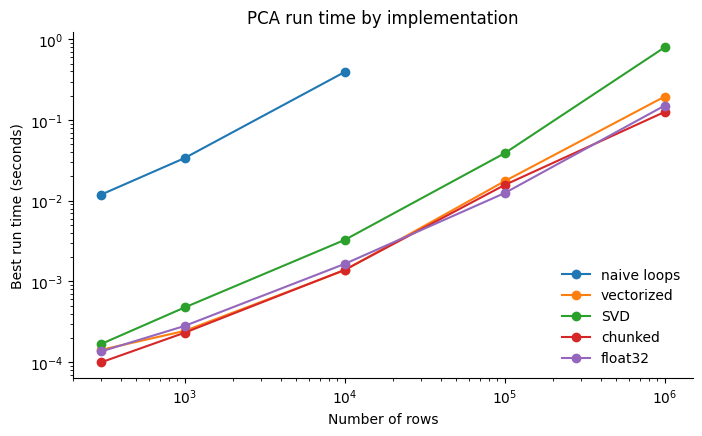

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name in fns:
    ax.plot(sizes, results[name], marker="o", label=name)
ax.set(xscale="log", yscale="log", xlabel="Number of rows", ylabel="Best run time (seconds)",
       title="PCA run time by implementation")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.show()

**Memory.** Speed is only part of handling large data. Peak extra memory is compared for the vectorized and chunked versions on 1,000,000 rows.

In [ ]:
big = make_large(X, 1_000_000)
for name, fn in {"vectorized": pca_vectorized, "chunked": pca_chunked}.items():
    tracemalloc.start()
    fn(big)
    peak = tracemalloc.get_traced_memory()[1] / 1e6
    tracemalloc.stop()
    print(f"{name:<12} peak extra memory: {peak:,.0f} MB")

# Precision cost of the float32 version on the large dataset
v64 = pca_vectorized(big)[0]
v32 = pca_float32(big)[0]
print(f"float32 max abs eigenvalue error: {np.max(np.abs(v64 - v32)):.2e}")

vectorized   peak extra memory: 192 MB
chunked      peak extra memory: 14 MB
float32 max abs eigenvalue error: 4.44e-03


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1. **What the before and after plots show?**
So the first plot ony uses two out of 12 columns, which is very difficult to study as it creates ambiguity, as for the second plot, with all the 12 columns, and five separate sites into clear groups you are able to see into clear groups. These two scores only holds approximately 53% of the information in the data. PC1 is mostly altitude, latitude and Burera and PC2 is mostly Kayonza, Kamonyi and longitude. The site columns were inputs to the PCA.
2. **Why we kept 6 components, and what we give up?**
We kept them all 6 because we had a target of 90% and together they
hold 91.1% of the information, and this cuts the data from 12 columns to exactly 6. The thing is that the 8.9% remaining is from PC7 to PC12 with PC7 and PC8 holding almost all the 8.9% they have approximately 8.2%. Keeping 7 components would have given us 96%, but with the 6 components we already had above 90% our target and keeping 4 would have given us 77% which is too low.
3. **What information is lost in this dataset?**
The village as shown loses almost 25.6%, sector loses 24.5% and interview month loses 23.2%. Each of the remaining kept above 92% loosing slightly under 8%. with interview day keeping almost 100% (99.9%). what we lost in this data set is mostly the local details the village and sector of a farm, and its month of interview.

